# 使用GPT-4o API提取关键词并评估

本notebook实现以下功能：
1. 读取各章节txt文件
2. 使用GPT-4o API提取关键词
3. 使用index_by_chapter.txt评估提取结果

In [3]:
import os
import json
import requests
import pandas as pd
import time
from tqdm import tqdm
import re
from dotenv import load_dotenv

# 加载环境变量
load_dotenv()

# 获取API密钥
API_KEY = os.getenv("OPENAI_API_KEY")
if not API_KEY:
    raise ValueError("请在.env文件中设置OPENAI_API_KEY")

## 1. 读取章节文本文件

In [7]:
def read_chapter_files(data_dir="e:\\newdownload\\25spring\\class\\machine learning\\project\\extractkeyword\\data\\train"):
    """读取所有章节文件"""
    chapter_files = {}
    
    # 获取所有txt文件
    for file in os.listdir(data_dir):
        if file.endswith(".txt") and file != "index_by_chapter.txt":
            chapter_path = os.path.join(data_dir, file)
            with open(chapter_path, 'r', encoding='utf-8') as f:
                content = f.read()
            chapter_files[file] = content
    
    return chapter_files

# 读取章节文件
chapter_files = read_chapter_files()
print(f"共读取了 {len(chapter_files)} 个章节文件")
print(f"文件列表: {list(chapter_files.keys())[:5]}...")

共读取了 15 个章节文件
文件列表: ['ch1.txt', 'ch13.txt', 'ch14.txt', 'ch15.txt', 'ch16.txt']...


## 2. 使用GPT-4o API提取关键词

In [8]:
def extract_keywords_with_gpt4o(text, max_keywords=20):
    """使用GPT-4o API提取关键词"""
    headers = {
        "Content-Type": "application/json",
        "Authorization": f"Bearer {API_KEY}"
    }
    
    # 构建提示词
    prompt = f"""请从以下文本中提取最重要的关键词或短语，最多{max_keywords}个。
    以JSON格式返回，格式为 {{'keywords': ['关键词1', '关键词2', ...]}}
    
    文本内容：
    {text}
    """
    
    payload = {
        "model": "gpt-4o",
        "messages": [
            {"role": "system", "content": "你是一个专业的关键词提取助手，擅长从文本中提取重要的关键词和短语。"},
            {"role": "user", "content": prompt}
        ],
        "temperature": 0.3
    }
    
    try:
        response = requests.post("https://api.openai.com/v1/chat/completions", headers=headers, json=payload)
        response.raise_for_status()
        result = response.json()
        
        # 提取关键词列表
        content = result['choices'][0]['message']['content']
        # 使用正则表达式提取JSON部分
        json_match = re.search(r'\{.*\}', content, re.DOTALL)
        if json_match:
            try:
                keywords_json = json.loads(json_match.group())
                return keywords_json.get('keywords', [])
            except json.JSONDecodeError:
                # 如果JSON解析失败，尝试直接从文本中提取关键词
                keywords = re.findall(r'"([^"]+)"', content)
                return keywords[:max_keywords]
        else:
            # 如果没有找到JSON格式，尝试直接从文本中提取关键词
            keywords = re.findall(r'"([^"]+)"', content)
            return keywords[:max_keywords]
            
    except Exception as e:
        print(f"API调用出错: {e}")
        return []

# 测试API调用
test_text = list(chapter_files.values())[0][:1000]  # 使用第一个章节的前1000个字符测试
test_keywords = extract_keywords_with_gpt4o(test_text, max_keywords=5)
print(f"测试提取的关键词: {test_keywords}")

测试提取的关键词: ['Machine Learning', 'Optical Character Recognition (OCR)', 'spam filter', 'recommendations', 'voice search']


In [11]:
# 为所有章节提取关键词
chapter_keywords = {}

for chapter_name, chapter_text in tqdm(chapter_files.items(), desc="提取关键词"):
    keywords = extract_keywords_with_gpt4o(chapter_text)
    chapter_keywords[chapter_name] = keywords
    # 避免API限流
    time.sleep(1)

# 保存提取结果
with open("e:\\newdownload\\25spring\\class\\machine learning\\project\\extractkeyword\\results\\gpt4o_keywords.json", "w", encoding="utf-8") as f:
    json.dump(chapter_keywords, f, ensure_ascii=False, indent=2)

提取关键词: 100%|██████████| 15/15 [01:15<00:00,  5.04s/it]


## 3. 读取标准答案并评估

In [13]:
def read_ground_truth(file_path="e:\\newdownload\\25spring\\class\\machine learning\\project\\extractkeyword\\data\\index_by_chapter.txt"):
    """读取标准答案文件"""
    ground_truth = {}
    
    with open(file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()
    
    current_chapter = None
    for line in lines:
        line = line.strip()
        if not line:
            continue
        
        # 检查是否是章节标题行
        if line.startswith("Chapter") or line.startswith("章节"):
            current_chapter = line
            ground_truth[current_chapter] = []
        elif current_chapter and line:  # 如果是关键词行
            keywords = [kw.strip() for kw in line.split(',')]
            ground_truth[current_chapter].extend(keywords)
    
    return ground_truth

# 读取标准答案
ground_truth = read_ground_truth()
print(f"共读取了 {len(ground_truth)} 个章节的标准答案")

共读取了 19 个章节的标准答案


In [14]:
def calculate_metrics(true_keywords, pred_keywords):
    """计算评估指标"""
    # 转换为小写并去重
    true_set = set([kw.lower() for kw in true_keywords])
    pred_set = set([kw.lower() for kw in pred_keywords])
    
    # 计算交集
    intersection = true_set.intersection(pred_set)
    
    # 计算指标
    precision = len(intersection) / len(pred_set) if pred_set else 0
    recall = len(intersection) / len(true_set) if true_set else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0
    
    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "true_positives": list(intersection)
    }

# 将文件名映射到章节名
def map_filename_to_chapter(filename, ground_truth_keys):
    """尝试将文件名映射到标准答案中的章节名"""
    # 提取文件名中的章节号
    chapter_num_match = re.search(r'chapter[_\s]*(\d+)', filename.lower())
    if not chapter_num_match:
        return None
    
    chapter_num = chapter_num_match.group(1)
    
    # 查找匹配的章节名
    for chapter_name in ground_truth_keys:
        if chapter_num in chapter_name.lower():
            return chapter_name
    
    return None

In [ ]:
# 检查标准答案数据格式
print("\n标准答案数据格式检查:")
for chapter_name, keywords in list(ground_truth.items())[:3]:  # 只显示前3个章节
    print(f"章节: {chapter_name}")
    print(f"关键词数量: {len(keywords)}")
    print(f"关键词示例: {keywords[:5]}...")
    print()


标准答案数据格式检查:
章节: Chapter 1
关键词数量: 93
关键词示例: ['cross-validation', 'agents', 'clustering algorithms', 'hierarchical clustering algorithms', 'importance of data over']...

章节: Chapter 2
关键词数量: 86
关键词示例: ['cross-validation', 'evaluating', 'average absolute deviation', 'California Housing Prices dataset', 'MNIST dataset']...

章节: Chapter 3
关键词数量: 47
关键词示例: ['accuracy', 'cross-validation', 'area under the curve', 'AUC', 'binary classifiers']...



In [17]:

# 检查map_filename_to_chapter函数的实现
def map_filename_to_chapter(filename, ground_truth_keys):
    """尝试将文件名映射到标准答案中的章节名"""
    # 打印调试信息
    print(f"尝试映射文件名: {filename}")
    print(f"可用的标准答案章节: {list(ground_truth_keys)}")
    
    # 提取文件名中的章节号
    chapter_num_match = re.search(r'chapter[_\s]*(\d+)', filename.lower())
    if not chapter_num_match:
        # 尝试其他可能的模式
        chapter_num_match = re.search(r'chap[_\s]*(\d+)', filename.lower())
        if not chapter_num_match:
            chapter_num_match = re.search(r'ch[_\s]*(\d+)', filename.lower())
            if not chapter_num_match:
                # 尝试直接提取数字
                chapter_num_match = re.search(r'(\d+)', filename.lower())
                if not chapter_num_match:
                    print(f"  无法从文件名 {filename} 提取章节号")
                    return None
    
    chapter_num = chapter_num_match.group(1)
    print(f"  提取的章节号: {chapter_num}")
    
    # 查找匹配的章节名
    for chapter_name in ground_truth_keys:
        if chapter_num in chapter_name.lower():
            print(f"  匹配到章节: {chapter_name}")
            return chapter_name
    
    print(f"  未找到匹配章节号 {chapter_num} 的标准答案")
    return None

In [23]:
# 评估结果
evaluation_results = []

# 添加调试信息
print(f"章节关键词数量: {len(chapter_keywords)}")
print(f"标准答案章节数量: {len(ground_truth)}")

for filename, keywords in chapter_keywords.items():
    chapter_name = map_filename_to_chapter(filename, ground_truth.keys())
    
    # 添加调试信息
    print(f"处理文件: {filename} -> 映射章节: {chapter_name}")
    
    if chapter_name and chapter_name in ground_truth:
        true_keywords = ground_truth[chapter_name]
        metrics = calculate_metrics(true_keywords, keywords)
        
        evaluation_results.append({
            "filename": filename,
            "chapter_name": chapter_name,
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "f1": metrics["f1"],
            "true_positives": metrics["true_positives"],
            "predicted_keywords": keywords,
            "ground_truth": true_keywords
        })
    else:
        print(f"警告: 无法找到文件 {filename} 对应的标准答案章节")

# 检查评估结果是否为空
if not evaluation_results:
    print("警告: 评估结果为空! 请检查章节映射和标准答案格式。")
    # 创建一个包含默认值的DataFrame以避免KeyError
    results_df = pd.DataFrame({
        "chapter_name": ["无匹配章节"],
        "precision": [0.0],
        "recall": [0.0],
        "f1": [0.0]
    })
    avg_metrics = pd.Series({"precision": 0.0, "recall": 0.0, "f1": 0.0})
else:
    # 转换为DataFrame并计算平均指标
    results_df = pd.DataFrame(evaluation_results)
    avg_metrics = results_df[["precision", "recall", "f1"]].mean()

print("\n平均评估指标:")
print(f"Precision: {avg_metrics['precision']:.4f}")
print(f"Recall: {avg_metrics['recall']:.4f}")
print(f"F1 Score: {avg_metrics['f1']:.4f}")

# 显示详细结果
if not evaluation_results:
    print("无有效评估结果")
else:
    display(results_df[["chapter_name", "precision", "recall", "f1"]])

章节关键词数量: 15
标准答案章节数量: 19
尝试映射文件名: ch1.txt
可用的标准答案章节: ['Chapter 1', 'Chapter 2', 'Chapter 3', 'Chapter 4', 'Chapter 5', 'Chapter 6', 'Chapter 7', 'Chapter 8', 'Chapter 9', 'Chapter 10', 'Chapter 11', 'Chapter 12', 'Chapter 13', 'Chapter 14', 'Chapter 15', 'Chapter 16', 'Chapter 17', 'Chapter 18', 'Chapter 19']
  提取的章节号: 1
  匹配到章节: Chapter 1
处理文件: ch1.txt -> 映射章节: Chapter 1
尝试映射文件名: ch13.txt
可用的标准答案章节: ['Chapter 1', 'Chapter 2', 'Chapter 3', 'Chapter 4', 'Chapter 5', 'Chapter 6', 'Chapter 7', 'Chapter 8', 'Chapter 9', 'Chapter 10', 'Chapter 11', 'Chapter 12', 'Chapter 13', 'Chapter 14', 'Chapter 15', 'Chapter 16', 'Chapter 17', 'Chapter 18', 'Chapter 19']
  提取的章节号: 13
  匹配到章节: Chapter 13
处理文件: ch13.txt -> 映射章节: Chapter 13
尝试映射文件名: ch14.txt
可用的标准答案章节: ['Chapter 1', 'Chapter 2', 'Chapter 3', 'Chapter 4', 'Chapter 5', 'Chapter 6', 'Chapter 7', 'Chapter 8', 'Chapter 9', 'Chapter 10', 'Chapter 11', 'Chapter 12', 'Chapter 13', 'Chapter 14', 'Chapter 15', 'Chapter 16', 'Chapter 17', 'Chapter 18

,chapter_name,precision,recall,f1
0,Chapter 1,0.650000,0.139785,0.230088
1,Chapter 13,0.300000,0.115385,0.166667
2,Chapter 14,0.526316,0.113636,0.186916
3,Chapter 15,0.450000,0.150000,0.225000
4,Chapter 16,0.200000,0.049383,0.079208
5,Chapter 17,0.500000,0.129870,0.206186
6,Chapter 18,0.350000,0.071429,0.118644
7,Chapter 19,0.100000,0.016807,0.028777
8,Chapter 2,0.200000,0.046512,0.075472
9,Chapter 3,0.473684,0.191489,0.272727


In [18]:
# 评估结果
evaluation_results = []

for filename, keywords in chapter_keywords.items():
    chapter_name = map_filename_to_chapter(filename, ground_truth.keys())
    
    if chapter_name and chapter_name in ground_truth:
        true_keywords = ground_truth[chapter_name]
        metrics = calculate_metrics(true_keywords, keywords)
        
        evaluation_results.append({
            "filename": filename,
            "chapter_name": chapter_name,
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "f1": metrics["f1"],
            "true_positives": metrics["true_positives"],
            "predicted_keywords": keywords,
            "ground_truth": true_keywords
        })

# 转换为DataFrame并计算平均指标
results_df = pd.DataFrame(evaluation_results)
avg_metrics = results_df[["precision", "recall", "f1"]].mean()

print("\n平均评估指标:")
print(f"Precision: {avg_metrics['precision']:.4f}")
print(f"Recall: {avg_metrics['recall']:.4f}")
print(f"F1 Score: {avg_metrics['f1']:.4f}")

# 显示详细结果
results_df[["chapter_name", "precision", "recall", "f1"]]

尝试映射文件名: ch1.txt
可用的标准答案章节: ['Chapter 1', 'Chapter 2', 'Chapter 3', 'Chapter 4', 'Chapter 5', 'Chapter 6', 'Chapter 7', 'Chapter 8', 'Chapter 9', 'Chapter 10', 'Chapter 11', 'Chapter 12', 'Chapter 13', 'Chapter 14', 'Chapter 15', 'Chapter 16', 'Chapter 17', 'Chapter 18', 'Chapter 19']
  提取的章节号: 1
  匹配到章节: Chapter 1
尝试映射文件名: ch13.txt
可用的标准答案章节: ['Chapter 1', 'Chapter 2', 'Chapter 3', 'Chapter 4', 'Chapter 5', 'Chapter 6', 'Chapter 7', 'Chapter 8', 'Chapter 9', 'Chapter 10', 'Chapter 11', 'Chapter 12', 'Chapter 13', 'Chapter 14', 'Chapter 15', 'Chapter 16', 'Chapter 17', 'Chapter 18', 'Chapter 19']
  提取的章节号: 13
  匹配到章节: Chapter 13
尝试映射文件名: ch14.txt
可用的标准答案章节: ['Chapter 1', 'Chapter 2', 'Chapter 3', 'Chapter 4', 'Chapter 5', 'Chapter 6', 'Chapter 7', 'Chapter 8', 'Chapter 9', 'Chapter 10', 'Chapter 11', 'Chapter 12', 'Chapter 13', 'Chapter 14', 'Chapter 15', 'Chapter 16', 'Chapter 17', 'Chapter 18', 'Chapter 19']
  提取的章节号: 14
  匹配到章节: Chapter 14
尝试映射文件名: ch15.txt
可用的标准答案章节: ['Chapter 1', 

,chapter_name,precision,recall,f1
0,Chapter 1,0.650000,0.139785,0.230088
1,Chapter 13,0.300000,0.115385,0.166667
2,Chapter 14,0.526316,0.113636,0.186916
3,Chapter 15,0.450000,0.150000,0.225000
4,Chapter 16,0.200000,0.049383,0.079208
5,Chapter 17,0.500000,0.129870,0.206186
6,Chapter 18,0.350000,0.071429,0.118644
7,Chapter 19,0.100000,0.016807,0.028777
8,Chapter 2,0.200000,0.046512,0.075472
9,Chapter 3,0.473684,0.191489,0.272727


## 4. 可视化评估结果

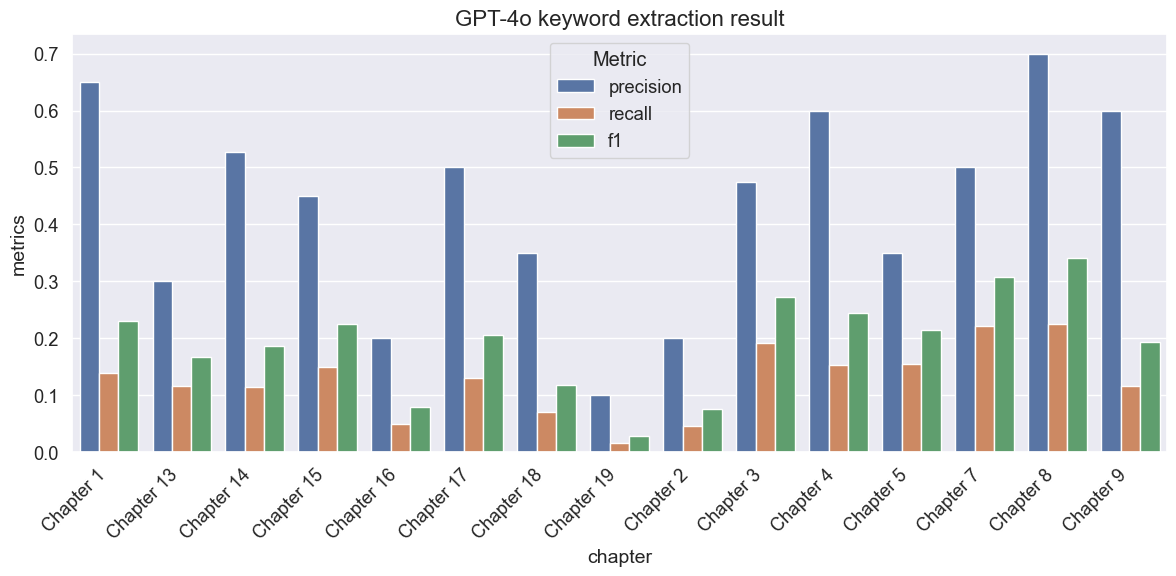

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# 设置样式
plt.style.use('ggplot')
sns.set(font_scale=1.2)

# 创建评估指标可视化
plt.figure(figsize=(12, 6))
metrics_df = results_df[["chapter_name", "precision", "recall", "f1"]].melt(
    id_vars=["chapter_name"],
    var_name="Metric",
    value_name="Value"
)

# 绘制柱状图
ax = sns.barplot(x="chapter_name", y="Value", hue="Metric", data=metrics_df)
plt.title("GPT-4o keyword extraction result", fontsize=16)
plt.xlabel("chapter", fontsize=14)
plt.ylabel("metrics", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("e:\\newdownload\\25spring\\class\\machine learning\\project\\extractkeyword\\results\\gpt4o_evaluation.png", dpi=300)
plt.show()

# 保存评估结果
results_df.to_csv("e:\\newdownload\\25spring\\class\\machine learning\\project\\extractkeyword\\results\\gpt4o_evaluation.csv", index=False, encoding="utf-8")

## 5. 分析结果

In [ ]:
# 分析每个章节的关键词提取情况
for idx, row in results_df.iterrows():
    print(f"\n章节: {row['chapter_name']}")
    print(f"Precision: {row['precision']:.4f}, Recall: {row['recall']:.4f}, F1: {row['f1']:.4f}")
    
    # 显示正确提取的关键词
    print(f"正确提取的关键词 ({len(row['true_positives'])}):\n{', '.join(row['true_positives'])}")
    
    # 显示未提取到的关键词
    missed = set([kw.lower() for kw in row['ground_truth']]) - set([kw.lower() for kw in row['true_positives']])
    print(f"\n未提取到的关键词 ({len(missed)}):\n{', '.join(missed)}")
    
    # 显示错误提取的关键词
    false_positives = set([kw.lower() for kw in row['predicted_keywords']]) - set([kw.lower() for kw in row['true_positives']])
    print(f"\n错误提取的关键词 ({len(false_positives)}):\n{', '.join(false_positives)}")
    print("-" * 80)


章节: Chapter 1
Precision: 0.6500, Recall: 0.1398, F1: 0.2301
正确提取的关键词 (13):
unsupervised learning, online learning, instance-based learning, feature engineering, model-based learning, clustering, overfitting, supervised learning, batch learning, reinforcement learning, machine learning, underfitting, regularization

未提取到的关键词 (80):
algorithms covered, agents, association rule learning, visualization algorithms, training data, ocr, ml, out-of-sample error, generalization error, out-of-core learning, training samples, cross-validation, linear models, mini-batches, hold outs, feature extraction, training instances, model selection, anomaly detection, feature selection, training sets, regression problems, data mismatch, sampling noise, corpus development, attributes, train-dev sets, hierarchical clustering algorithms, development sets, rbms, poor quality, hyperparameter tuning, training, rl, fitness functions, penalties, spam filters, inference, fully-specified model architecture, classific

In [24]:
# 分析每个章节的关键词提取情况并保存结果
analysis_output_path = "e:\\newdownload\\25spring\\class\\machine learning\\project\\extractkeyword\\results\\gpt4o_detailed_analysis.txt"

# 打开文件准备写入
with open(analysis_output_path, 'w', encoding='utf-8') as f:
    f.write("# GPT-4o关键词提取详细分析\n\n")
    
    for idx, row in results_df.iterrows():
        f.write(f"\n## 章节: {row['chapter_name']}\n")
        f.write(f"Precision: {row['precision']:.4f}, Recall: {row['recall']:.4f}, F1: {row['f1']:.4f}\n\n")
        
        # 写入正确提取的关键词
        f.write(f"### 正确提取的关键词 ({len(row['true_positives'])}):\n")
        f.write(f"{', '.join(row['true_positives'])}\n\n")
        
        # 写入未提取到的关键词
        missed = set([kw.lower() for kw in row['ground_truth']]) - set([kw.lower() for kw in row['true_positives']])
        f.write(f"### 未提取到的关键词 ({len(missed)}):\n")
        f.write(f"{', '.join(missed)}\n\n")
        
        # 写入错误提取的关键词
        false_positives = set([kw.lower() for kw in row['predicted_keywords']]) - set([kw.lower() for kw in row['true_positives']])
        f.write(f"### 错误提取的关键词 ({len(false_positives)}):\n")
        f.write(f"{', '.join(false_positives)}\n\n")
        f.write("-" * 80 + "\n")

    # 添加总结信息
    avg_metrics = results_df[["precision", "recall", "f1"]].mean()
    f.write("\n## 总体评估指标\n")
    f.write(f"平均Precision: {avg_metrics['precision']:.4f}\n")
    f.write(f"平均Recall: {avg_metrics['recall']:.4f}\n")
    f.write(f"平均F1 Score: {avg_metrics['f1']:.4f}\n")

# 同时在控制台输出原始分析结果
for idx, row in results_df.iterrows():
    print(f"\n章节: {row['chapter_name']}")
    print(f"Precision: {row['precision']:.4f}, Recall: {row['recall']:.4f}, F1: {row['f1']:.4f}")
    
    # 显示正确提取的关键词
    print(f"正确提取的关键词 ({len(row['true_positives'])}):\n{', '.join(row['true_positives'])}")
    
    # 显示未提取到的关键词
    missed = set([kw.lower() for kw in row['ground_truth']]) - set([kw.lower() for kw in row['true_positives']])
    print(f"\n未提取到的关键词 ({len(missed)}):\n{', '.join(missed)}")
    
    # 显示错误提取的关键词
    false_positives = set([kw.lower() for kw in row['predicted_keywords']]) - set([kw.lower() for kw in row['true_positives']])
    print(f"\n错误提取的关键词 ({len(false_positives)}):\n{', '.join(false_positives)}")
    print("-" * 80)

print(f"\n详细分析结果已保存到: {analysis_output_path}")


章节: Chapter 1
Precision: 0.6500, Recall: 0.1398, F1: 0.2301
正确提取的关键词 (13):
unsupervised learning, online learning, instance-based learning, feature engineering, model-based learning, clustering, overfitting, supervised learning, batch learning, reinforcement learning, machine learning, underfitting, regularization

未提取到的关键词 (80):
algorithms covered, agents, association rule learning, visualization algorithms, training data, ocr, ml, out-of-sample error, generalization error, out-of-core learning, training samples, cross-validation, linear models, mini-batches, hold outs, feature extraction, training instances, model selection, anomaly detection, feature selection, training sets, regression problems, data mismatch, sampling noise, corpus development, attributes, train-dev sets, hierarchical clustering algorithms, development sets, rbms, poor quality, hyperparameter tuning, training, rl, fitness functions, penalties, spam filters, inference, fully-specified model architecture, classific